# GSE214695 初步分析
结肠组织样本，选取其中的9个样本进行分析（排除其中的CD和直肠样本）  
3UC，6HC
- UC5-UC6
- HC5-HC10


# 文件说明
- **文件名**: 2_GSE214695.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-10-22  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/2_GSE214695_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set()
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


## 读取MTX类型数据

In [2]:
import os

data_dirs = ["/mnt/e/UC/scRNA-seq_RAW/1_GSE214695"]
adatas = []

for data_dir in data_dirs:
    for sample in sorted(os.listdir(data_dir)):
        path = os.path.join(data_dir, sample)
        if not os.path.isdir(path):
            continue

        ad = sc.read_10x_mtx(path, var_names='gene_symbols', cache=False)
        sc.pp.filter_cells(ad, min_genes=200)
        sc.pp.filter_genes(ad, min_cells=3)

        ad.obs['GSM_id'] = sample
        ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names] 
        adatas.append(ad)     

adata = sc.concat(adatas, merge='same')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 735576 cells that have less than 200 genes expressed
filtered out 17486 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 6791266 cells that have less than 200 genes expressed
filtered out 14675 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 6790039 cells that have less than 200 genes expressed
filtered out 14582 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 6791596 cells that have less than 200 genes expressed
filtered out 15311 genes that are detected in less than 3 cells
--> This might be very sl

In [3]:
adata

AnnData object with n_obs × n_vars = 28312 × 13188
    obs: 'n_genes', 'GSM_id'
    var: 'gene_ids', 'feature_types'

In [4]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM6614350_HC7     4841
GSM6614352_HC9     4374
GSM6614349_HC6     3614
GSM6614357_UC7     3417
GSM6614351_HC8     3284
GSM6614355_UC6     3017
GSM6614353_HC10    2534
GSM6614348_HC5     1704
GSM6614354_UC5     1527
Name: count, dtype: int64

In [5]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [6]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)
adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||-------------------------- 2559/16311 MiB (15.7%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 28,312 cells × 13,188 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 8888 (range: 237-272807)
     • Mean genes: 1203 (range: 184-10021)
     • Mean mitochondrial %: 20.2% (max: 97.6%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 910 cells failed (3.2%)
     • Genes filter (≥250): 1,585 cells failed (5.6%)
     • Mitochondrial filter (≤0.2): 9,359 cells failed (33.1%)
   ✓ Combined QC filters: 10,339 cells removed (36.5%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes

AnnData object with n_obs × n_vars = 17969 × 13188
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）

In [7]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "2_GSE214695.h5ad"), compression='gzip')

In [8]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.5)

Begin robust gene identification
After filtration, 13188/13188 genes are kept.     Among 13188 genes, 13188 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'JCHAIN', 'HBB', 'FTH1', 'MALAT1', 'IGHG4', 'IGHG2', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'PHGR1', 'ZG16', 'PLCG2', 'IGLL5', 'IGLC2', 'IGLC3', 'IGLC7']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 1.569037914276123 seconds.
End of size normali

In [9]:
adata

AnnData object with n_obs × n_vars = 17969 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [10]:
adata.obs['id'].value_counts()

id
UC7     3129
UC6     2475
HC9     2425
HC7     2424
HC6     2320
HC5     1464
UC5     1418
HC8     1185
HC10    1129
Name: count, dtype: int64

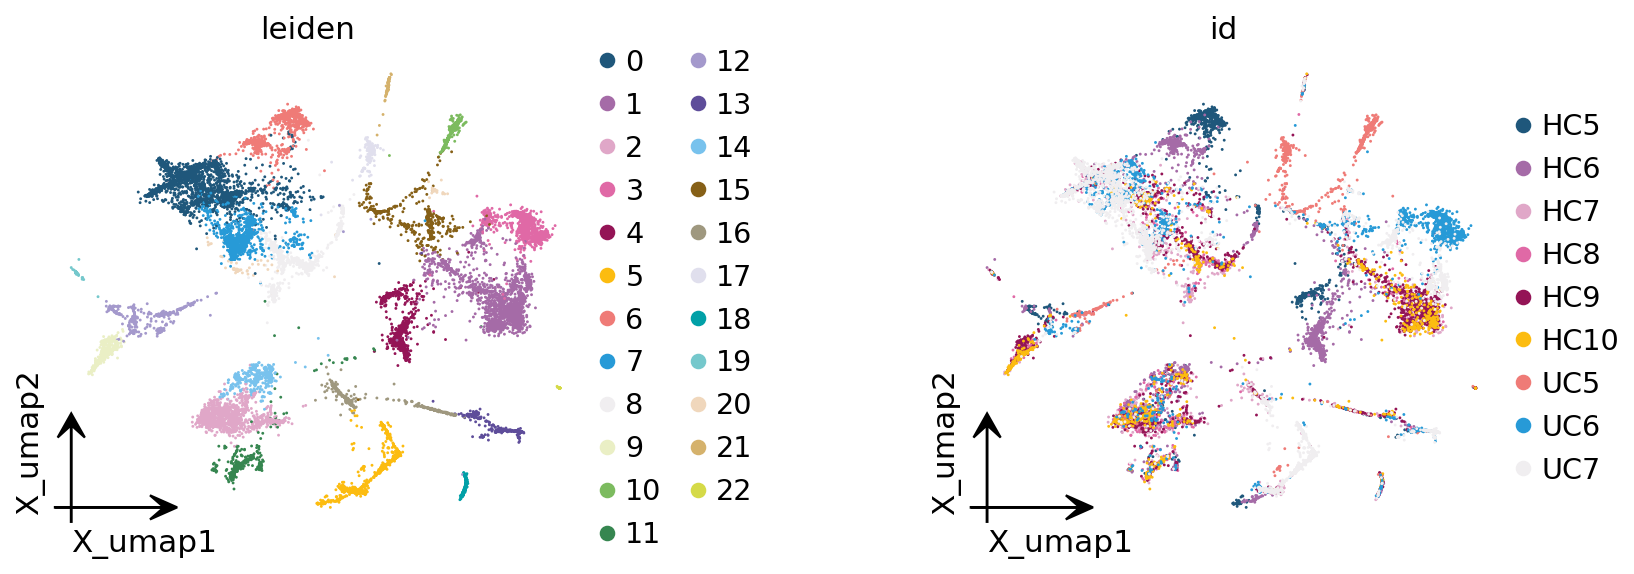

In [11]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

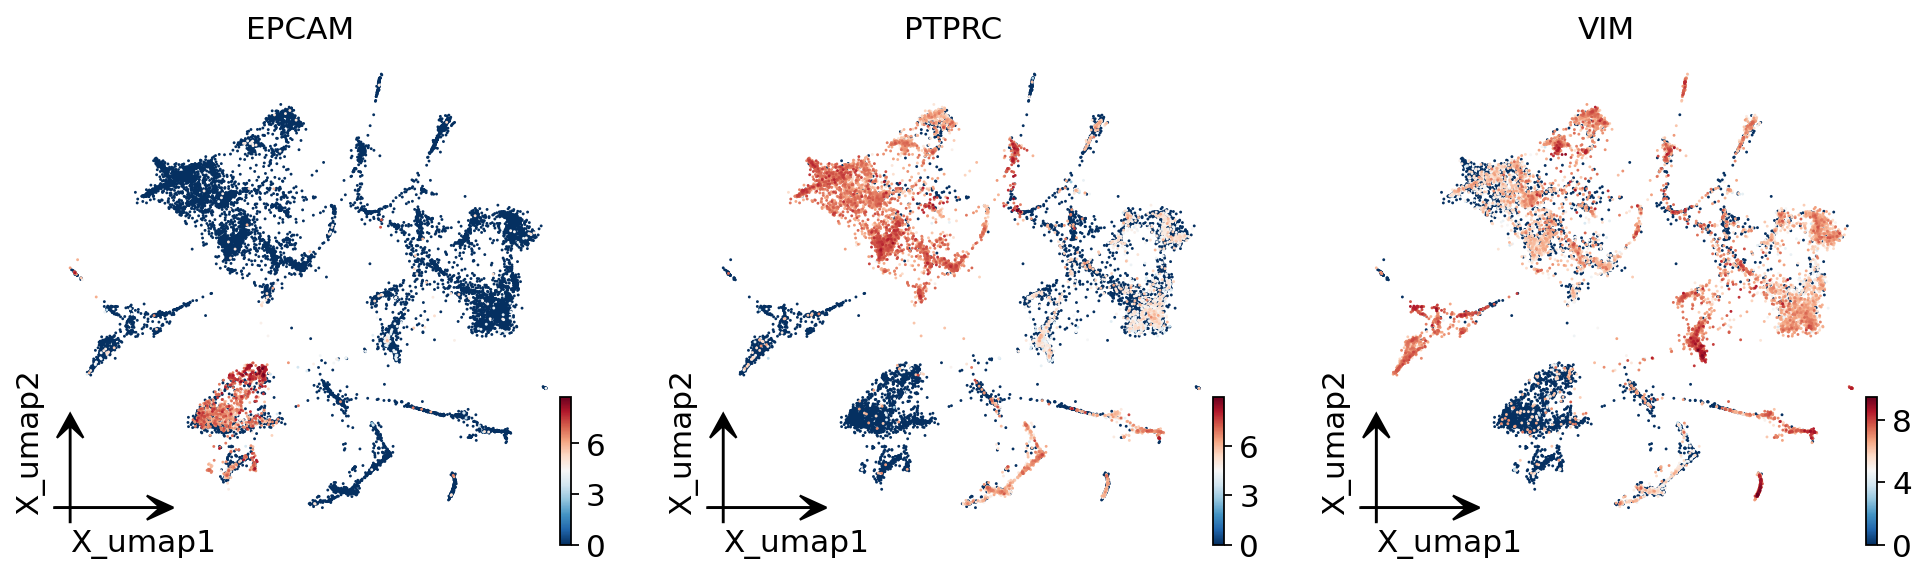

In [12]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

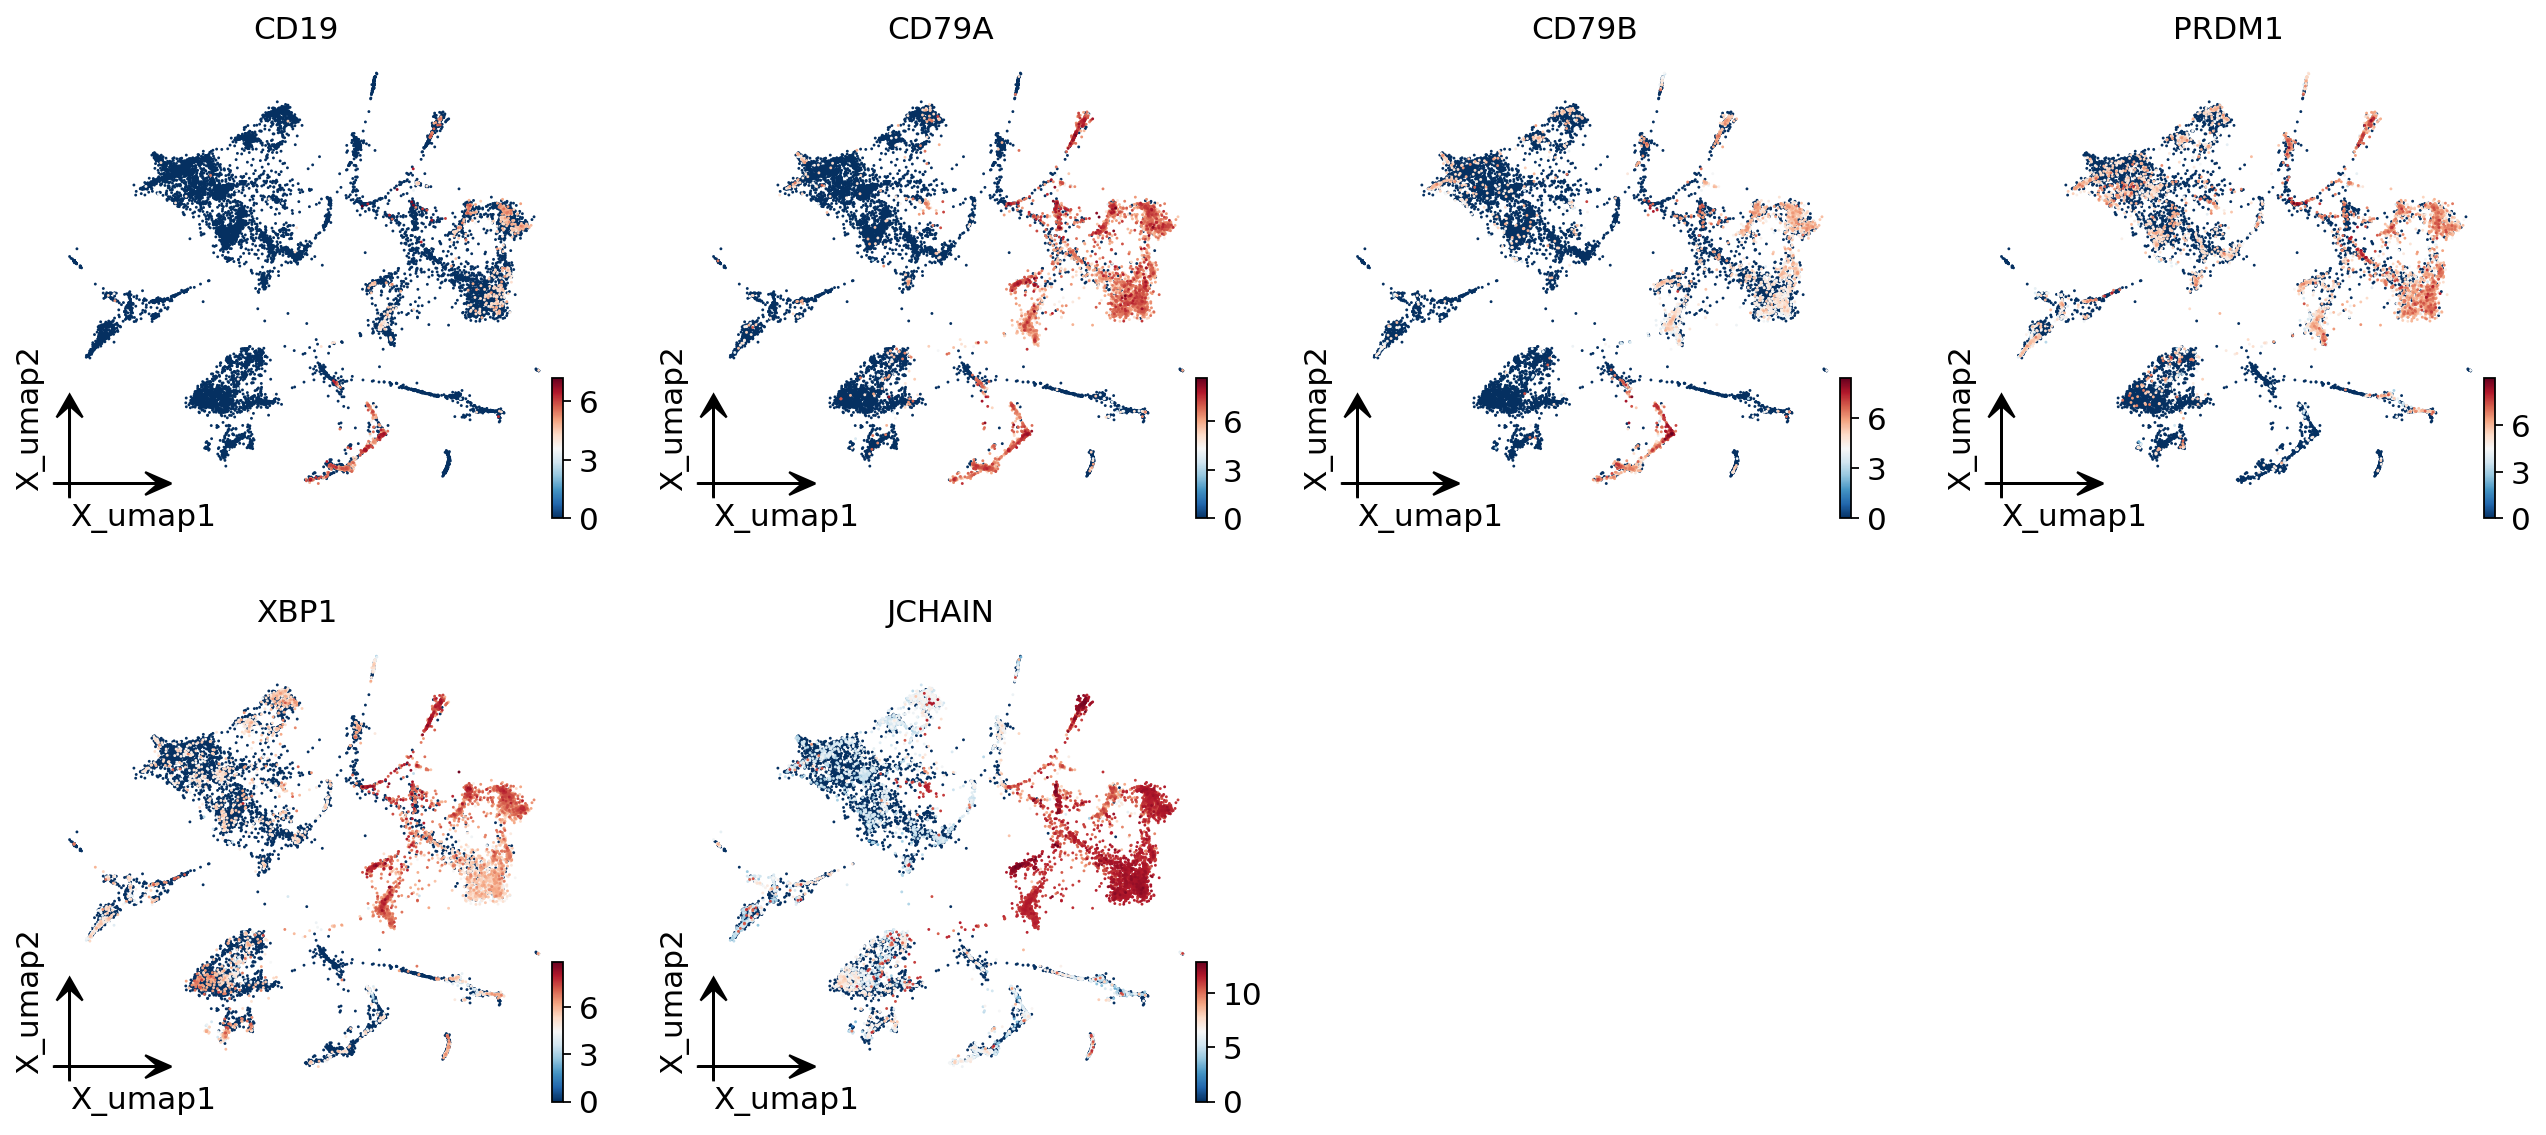

In [13]:
# 查看B细胞和浆细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD19',  'CD79A', 'CD79B',  'PRDM1', 'XBP1', 'JCHAIN'],
                frameon='small')

## GPT自动注释

In [14]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


{'0': ['IL32',
  'CREM',
  'CD3E',
  'CD3D',
  'SRGN',
  'TRAC',
  'PTPRC',
  'TRBC2',
  'IL7R',
  'CD2'],
 '1': ['MZB1',
  'DERL3',
  'SEC61B',
  'UBC',
  'TENT5C',
  'JCHAIN',
  'SEC11C',
  'ANKRD28',
  'TNFRSF17',
  'SSR4'],
 '10': ['RPS26',
  'SEC62',
  'HERPUD1',
  'HSP90B1',
  'PPIB',
  'SPCS3',
  'TMEM258',
  'SPCS2',
  'SSR4',
  'SERP1'],
 '11': ['LGALS4',
  'MUC2',
  'KRT18',
  'AGR2',
  'KRT8',
  'ELF3',
  'TFF3',
  'FCGBP',
  'ITLN1',
  'S100A6'],
 '12': ['IGFBP7',
  'CALD1',
  'RARRES2',
  'TIMP1',
  'COL6A2',
  'COL6A1',
  'CXCL14',
  'COL1A1',
  'COL3A1',
  'IFITM3'],
 '13': ['NAMPT',
  'LYZ',
  'FCER1G',
  'PLAUR',
  'HLA-DRB1',
  'S100A11',
  'AIF1',
  'TYROBP',
  'HLA-DRA',
  'SOD2'],
 '14': ['LGALS4',
  'PHGR1',
  'LGALS3',
  'KRT8',
  'GUCA2A',
  'IFI27',
  'FXYD3',
  'KRT20',
  'FABP1',
  'S100A6'],
 '15': ['IGLC2',
  'HSP90B1',
  'MZB1',
  'DERL3',
  'IGHA1',
  'IGKC',
  'IGHG1',
  'JCHAIN',
  'SEC11C',
  'SSR4'],
 '16': ['C1QB',
  'HLA-DRB1',
  'LYZ',
  'HLA-DQA1'

In [15]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell',
 '1': 'Plasma cell',
 '10': 'Endoplasmic reticulum stress response cell',
 '11': 'Goblet cell',
 '12': 'Fibroblast',
 '13': 'Macrophage',
 '14': 'Enterocyte',
 '15': 'Plasma cell',
 '16': 'Macrophage',
 '17': 'Mixed T cell and epithelial cell',
 '18': 'Mast cell',
 '19': 'Smooth muscle cell',
 '2': 'Epithelial cell',
 '20': 'Proliferating cell',
 '21': 'Pericyte',
 '22': 'Schwann cell',
 '3': 'Plasma cell',
 '4': 'Plasma cell',
 '5': 'Antigen-presenting cell',
 '6': 'Mixed T cell and ribosomal protein expressing cell',
 '7': 'Natural killer cell',
 '8': 'Natural killer cell',
 '9': 'Stromal cell'}

In [16]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

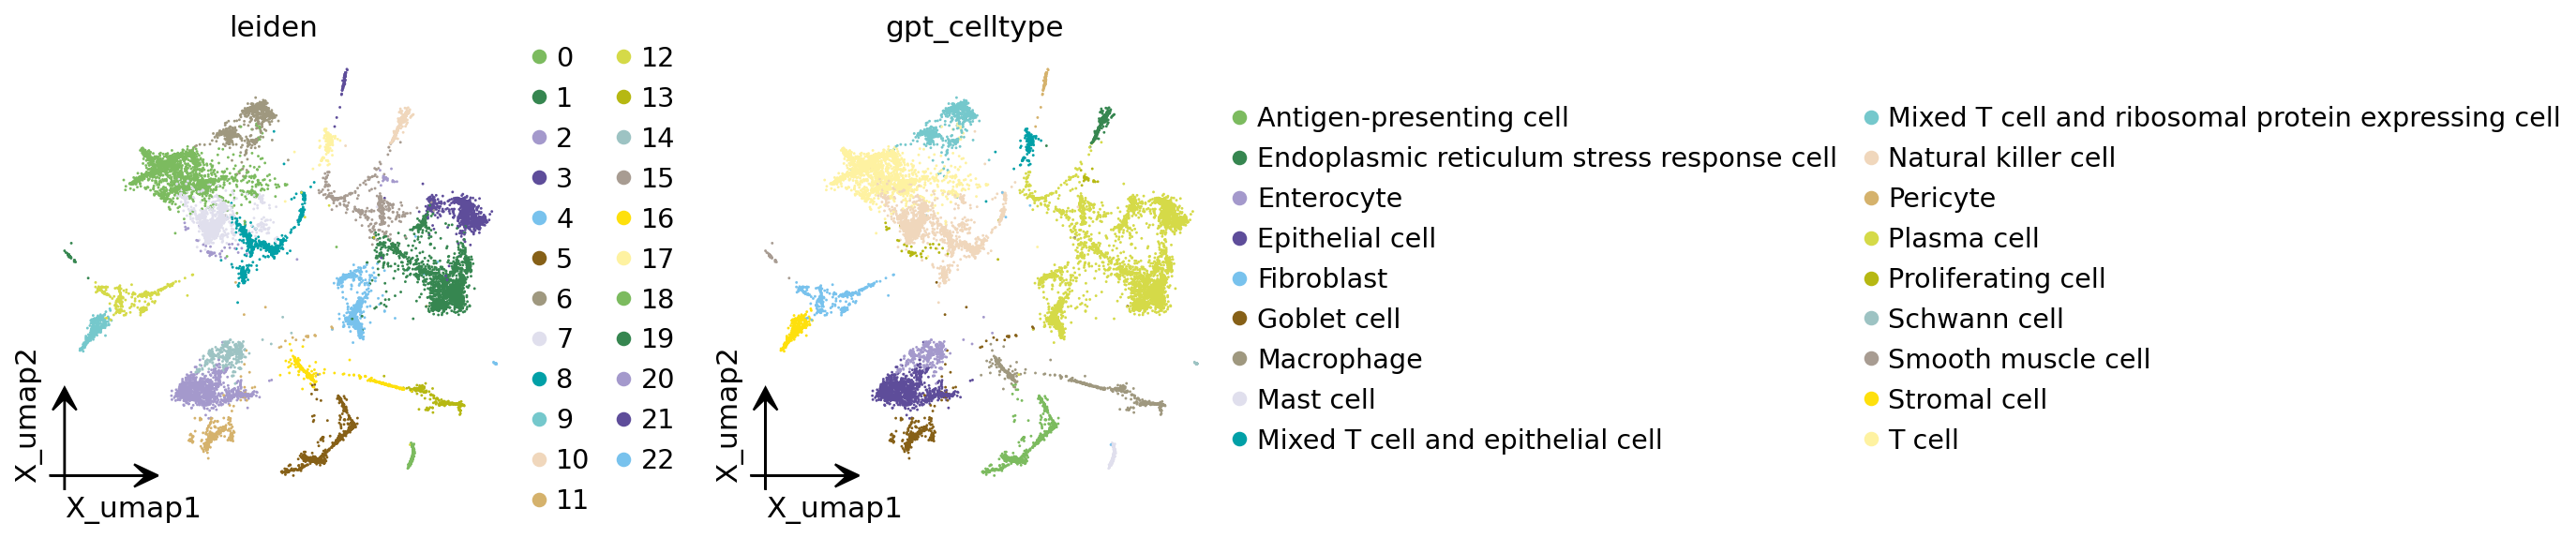

In [17]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [18]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Plasma cell                                           28.944293
T cell                                                12.159831
Natural killer cell                                   10.840893
Epithelial cell                                        8.113974
Antigen-presenting cell                                6.388781
Mixed T cell and ribosomal protein expressing cell     5.576270
Macrophage                                             5.003061
Stromal cell                                           4.251767
Endoplasmic reticulum stress response cell             3.233346
Goblet cell                                            3.083088
Fibroblast                                             3.071957
Enterocyte                                             2.754744
Mixed T cell and epithelial cell                       1.986755
Mast cell                                              1.958929
Smooth muscle cell                                     0.940509
Proliferating cell         

# 总结
疑问：
- 浆细胞数量很多，并且异常

优点：
- 上皮细胞正常了，并且gpt识别出为肠上皮细胞
